<a href="https://colab.research.google.com/github/SusmitaSahu365/Flight-delay-Analysis-using-apache-spark/blob/main/flight_delay_big_data_project.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Airline Delay Analytics Platform on Apache Spark
### A big data mini project: batch analytics, ML prediction, performance engineering and a streaming demo

**Dataset:** 2015 US Flight Delays and Cancellations (US DOT / BTS), 5.8M+ flights, 31 columns
https://www.kaggle.com/datasets/usdot/flight-delays

## Problem statement
Flight delays cost airlines and passengers billions every year. Using a multi-million-row flight dataset, this project builds an
end-to-end Spark pipeline that (1) explains **where, when and why** delays happen, (2) **predicts** whether a flight will be
delayed, (3) measures how Spark **engineering choices** change performance, and (4) shows how the same logic works on a **live stream**.

## Objectives
1. Build a reproducible ingestion and cleaning pipeline with a data quality report.
2. Store the data in a columnar format (Parquet) and query it with both the DataFrame API and Spark SQL.
3. Answer 15+ analytical questions covering airlines, airports, routes, time patterns, holidays, delay causes and cancellations.
4. Show **delay propagation**: how one late aircraft delays its next flights.
5. Train and compare Logistic Regression, Random Forest and Gradient-Boosted Trees; predict delay minutes with regression.
6. Benchmark CSV vs Parquet, caching, shuffle partitions and broadcast joins.
7. Simulate real-time delay monitoring with Spark Structured Streaming.
8. Export dashboard-ready tables for Power BI / Tableau.

## Architecture
```
 Kaggle CSVs ──► Spark (ingest, schema, quality report)
                      │
                      ▼
              Parquet (partitioned by month)
                      │
        ┌─────────────┼───────────────┬──────────────────┐
        ▼             ▼               ▼                  ▼
   Spark SQL /    Feature         Spark MLlib        Structured
   DataFrames     engineering     (LR / RF / GBT)    Streaming demo
   (analytics)    (windows,       classification     (live per-airline
        │          joins)         + regression       delay monitor)
        ▼             │               │
   Matplotlib /       └───────┬───────┘
   Plotly charts              ▼
        └────────► CSV exports for Power BI / Tableau
```

## Notebook map
| Part | Content |
|---|---|
| 1 | Setup and ingestion |
| 2 | Data engineering: quality report, Parquet, Spark SQL |
| 3 | Cleaning and feature engineering |
| 4 | Batch analytics (12 analyses) |
| 5 | Machine learning |
| 6 | Performance engineering |
| 7 | Streaming simulation |
| 8 | Dashboard exports and auto-generated findings |
| 9 | Conclusions and future work |

# Part 1. Setup and ingestion

In [ ]:
!pip install -q pyspark==3.5.3 setuptools kagglehub plotly seaborn

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 317.3/317.3 MB 4.5 MB/s eta 0:00:00
  Preparing metadata (setup.py) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 200.5/200.5 kB 22.8 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
dataproc-spark-connect 1.1.0 requires pyspark[connect]~=4.0.0, but you have pyspark 3.5.3 which is incompatible.


In [ ]:
import os, time, shutil, datetime as dt
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import plotly.express as px
from IPython.display import display
from pyspark.sql import SparkSession, Window, functions as F

sns.set_theme(style="whitegrid")

spark = (SparkSession.builder
         .appName("FlightDelayBigDataProject")
         .config("spark.driver.memory", "6g")
         .config("spark.sql.shuffle.partitions", "16")
         .config("spark.sql.ansi.enabled", "false")
         .getOrCreate())
spark.sparkContext.setLogLevel("ERROR")

# Working folder for Parquet, models and exports
WORK = "/content/flight_project"
os.makedirs(WORK, exist_ok=True)

# Tunable settings
MIN_AIRPORT_FLIGHTS = 10000    # ignore tiny airports in rankings
MIN_ROUTE_FLIGHTS   = 1000     # ignore rare routes in rankings
ML_SAMPLE_FRACTION  = 0.10     # share of flights used for ML (raise to 0.25+ if your runtime has the memory)
RUN_PANDAS_COMPARISON = True   # set False if Colab runs out of RAM in Part 6

print("Spark version:", spark.version)

Spark version: 3.5.3


`kagglehub` usually downloads public datasets without a Kaggle login. If it fails, download the zip from the Kaggle link,
upload the three CSVs to a Google Drive folder and use the commented Drive option.

In [ ]:
import kagglehub

path = kagglehub.dataset_download("usdot/flight-delays")

# --- Alternative: Google Drive ---
# from google.colab import drive
# drive.mount('/content/drive')
# path = "/content/drive/MyDrive/flight-delays"   # folder with flights.csv, airlines.csv, airports.csv

print(path)
print(os.listdir(path))

100%|██████████| 191M/191M [00:05<00:00, 34.5MB/s]

Extracting files...


/root/.cache/kagglehub/datasets/usdot/flight-delays/versions/1
['flights.csv', 'airlines.csv', 'airports.csv']


In [ ]:
flights  = spark.read.csv(f"{path}/flights.csv",  header=True, inferSchema=True)
airlines = spark.read.csv(f"{path}/airlines.csv", header=True, inferSchema=True)
airports = spark.read.csv(f"{path}/airports.csv", header=True, inferSchema=True)

csv_schema = flights.schema          # kept for the CSV-vs-Parquet benchmark in Part 6
total_rows = flights.count()
print(f"flights.csv: {total_rows:,} rows x {len(flights.columns)} columns")
flights.printSchema()
flights.show(5)

flights.csv: 5,819,079 rows x 31 columns
root
 |-- YEAR: integer (nullable = true)
 |-- MONTH: integer (nullable = true)
 |-- DAY: integer (nullable = true)
 |-- DAY_OF_WEEK: integer (nullable = true)
 |-- AIRLINE: string (nullable = true)
 |-- FLIGHT_NUMBER: integer (nullable = true)
 |-- TAIL_NUMBER: string (nullable = true)
 |-- ORIGIN_AIRPORT: string (nullable = true)
 |-- DESTINATION_AIRPORT: string (nullable = true)
 |-- SCHEDULED_DEPARTURE: integer (nullable = true)
 |-- DEPARTURE_TIME: integer (nullable = true)
 |-- DEPARTURE_DELAY: integer (nullable = true)
 |-- TAXI_OUT: integer (nullable = true)
 |-- WHEELS_OFF: integer (nullable = true)
 |-- SCHEDULED_TIME: integer (nullable = true)
 |-- ELAPSED_TIME: integer (nullable = true)
 |-- AIR_TIME: integer (nullable = true)
 |-- DISTANCE: integer (nullable = true)
 |-- WHEELS_ON: integer (nullable = true)
 |-- TAXI_IN: integer (nullable = true)
 |-- SCHEDULED_ARRIVAL: integer (nullable = true)
 |-- ARRIVAL_TIME: integer (nullable 

In [ ]:
# Lookup tables with friendly names for joins
airlines_lkp = (airlines
                .withColumnRenamed("AIRLINE", "AIRLINE_NAME")
                .withColumnRenamed("IATA_CODE", "AIRLINE"))

airports_lkp = airports.select(F.col("IATA_CODE").alias("ORIGIN_AIRPORT"),
                               F.col("AIRPORT").alias("AIRPORT_NAME"),
                               "CITY", "STATE", "LATITUDE", "LONGITUDE")

# Part 2. Data engineering

### 2.1 Data quality report: which columns have missing values?

,column,null_count,null_pct
25,CANCELLATION_REASON,5729195,98.46
27,SECURITY_DELAY,4755640,81.72
26,AIR_SYSTEM_DELAY,4755640,81.72
29,LATE_AIRCRAFT_DELAY,4755640,81.72
30,WEATHER_DELAY,4755640,81.72
28,AIRLINE_DELAY,4755640,81.72
22,ARRIVAL_DELAY,105071,1.81
15,ELAPSED_TIME,105071,1.81
16,AIR_TIME,105071,1.81
19,TAXI_IN,92513,1.59


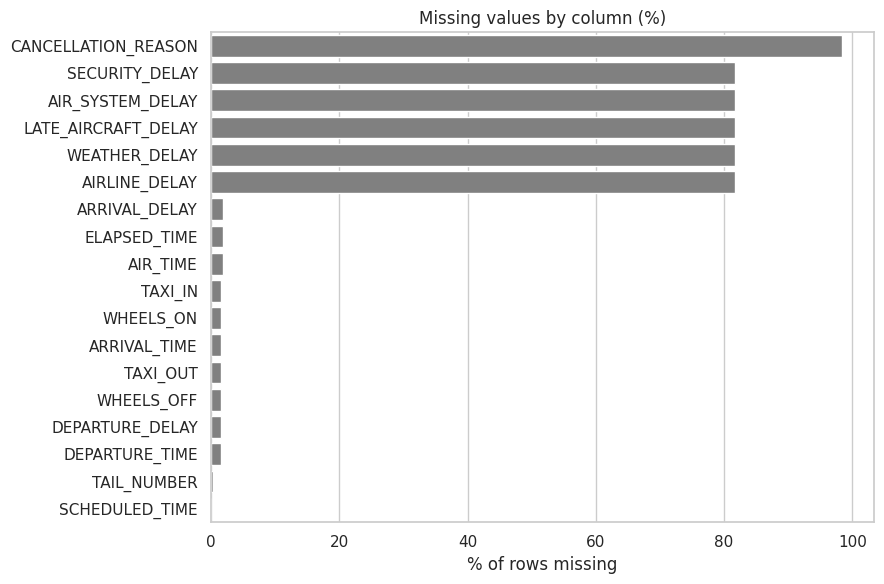

In [ ]:
null_pd = (flights.select([F.sum(F.col(c).isNull().cast("int")).alias(c) for c in flights.columns])
           .toPandas().T.reset_index())
null_pd.columns = ["column", "null_count"]
null_pd["null_pct"] = (100 * null_pd["null_count"] / total_rows).round(2)
null_pd = null_pd[null_pd["null_count"] > 0].sort_values("null_pct", ascending=False)
display(null_pd)

plt.figure(figsize=(9, 6))
sns.barplot(data=null_pd, x="null_pct", y="column", color="gray")
plt.title("Missing values by column (%)")
plt.xlabel("% of rows missing"); plt.ylabel("")
plt.tight_layout(); plt.show()

Most missing values are **expected, not errors**: cancelled flights have no departure or arrival times, and the five delay-cause
columns are only filled when a flight was actually delayed. Explain this in your report.

### 2.2 Convert CSV to partitioned Parquet

In [ ]:
PARQUET = f"{WORK}/flights_parquet"

t0 = time.time()
flights.write.mode("overwrite").partitionBy("MONTH").parquet(PARQUET)
print(f"Parquet write took {time.time() - t0:.1f}s")

def folder_size_mb(p):
    return sum(os.path.getsize(os.path.join(r, f)) for r, _, fs in os.walk(p) for f in fs) / 1e6

csv_mb = os.path.getsize(f"{path}/flights.csv") / 1e6
pq_mb = folder_size_mb(PARQUET)
print(f"CSV: {csv_mb:,.0f} MB | Parquet: {pq_mb:,.0f} MB | {csv_mb / pq_mb:.1f}x smaller")

# From here on, read from Parquet (columnar, compressed, typed)
flights = spark.read.parquet(PARQUET)
print("Rows read back from Parquet:", f"{flights.count():,}")

Parquet write took 46.9s
CSV: 592 MB | Parquet: 143 MB | 4.2x smaller
Rows read back from Parquet: 5,819,079


### 2.3 Spark SQL

In [ ]:
flights.createOrReplaceTempView("flights")
airlines.createOrReplaceTempView("airlines")
airports.createOrReplaceTempView("airports")

sql_airlines = '''
SELECT a.AIRLINE AS airline_name,
       COUNT(*) AS flights,
       ROUND(AVG(f.ARRIVAL_DELAY), 2) AS avg_arr_delay,
       ROUND(100 * AVG(CASE WHEN f.ARRIVAL_DELAY > 15 THEN 1 ELSE 0 END), 2) AS pct_delayed
FROM flights f
JOIN airlines a ON f.AIRLINE = a.IATA_CODE
WHERE f.CANCELLED = 0 AND f.DIVERTED = 0 AND f.ARRIVAL_DELAY IS NOT NULL
GROUP BY a.AIRLINE
ORDER BY pct_delayed DESC
'''
display(spark.sql(sql_airlines).toPandas())

,airline_name,flights,avg_arr_delay,pct_delayed
0,Spirit Air Lines,115193,14.47,28.79
1,Frontier Airlines Inc.,90090,12.50,25.36
2,JetBlue Airways,262042,6.68,21.85
3,American Eagle Airlines Inc.,278791,6.46,21.03
4,United Air Lines Inc.,507762,5.43,19.95
5,Atlantic Southeast Airlines,554752,6.59,18.99
6,Virgin America,61248,4.74,18.53
7,Southwest Airlines Co.,1242403,4.37,18.30
8,Skywest Airlines Inc.,576814,5.85,18.00
9,US Airways Inc.,194223,3.71,17.98


In [ ]:
# A CTE plus a window function: the 3 worst origin airports for every airline
sql_worst3 = '''
WITH airline_airport AS (
    SELECT AIRLINE, ORIGIN_AIRPORT, COUNT(*) AS flights,
           ROUND(AVG(DEPARTURE_DELAY), 2) AS avg_dep_delay
    FROM flights
    WHERE CANCELLED = 0 AND DEPARTURE_DELAY IS NOT NULL
      AND ORIGIN_AIRPORT RLIKE '^[A-Z]{3}$'
    GROUP BY AIRLINE, ORIGIN_AIRPORT
    HAVING COUNT(*) >= __MIN__
),
ranked AS (
    SELECT *, ROW_NUMBER() OVER (PARTITION BY AIRLINE ORDER BY avg_dep_delay DESC) AS rnk
    FROM airline_airport
)
SELECT AIRLINE, ORIGIN_AIRPORT, flights, avg_dep_delay, rnk
FROM ranked WHERE rnk <= 3
ORDER BY AIRLINE, rnk
'''.replace("__MIN__", str(max(MIN_AIRPORT_FLIGHTS // 5, 1)))
display(spark.sql(sql_worst3).toPandas())

,AIRLINE,ORIGIN_AIRPORT,flights,avg_dep_delay,rnk
0,AA,ORD,49733,13.14,1
1,AA,MIA,47832,13.01,2
2,AA,HNL,2385,12.73,3
3,AS,SFO,5144,7.87,1
4,AS,SEA,49930,3.61,2
5,AS,JNU,3854,3.57,3
6,B6,PBI,6592,17.66,1
7,B6,ORD,2214,17.58,2
8,B6,LGA,5978,15.90,3
9,DL,LGA,23807,14.70,1


# Part 3. Cleaning and feature engineering

In [ ]:
# US federal holidays in 2015 (July 4 fell on a Saturday, so it was observed on Friday July 3)
holidays_2015 = ["2015-01-01", "2015-01-19", "2015-02-16", "2015-05-25", "2015-07-03",
                 "2015-09-07", "2015-10-12", "2015-11-11", "2015-11-26", "2015-12-25"]
holiday_dates = [dt.date.fromisoformat(d) for d in holidays_2015]
near_holiday = sorted({(h + dt.timedelta(days=k)).isoformat() for h in holiday_dates for k in (-1, 0, 1)})

flights_fe = (flights
    .withColumn("FL_DATE", F.to_date(F.concat_ws("-", F.col("YEAR"),
                                                 F.lpad(F.col("MONTH").cast("string"), 2, "0"),
                                                 F.lpad(F.col("DAY").cast("string"), 2, "0"))))
    .withColumn("DEP_HOUR", (F.col("SCHEDULED_DEPARTURE") / 100).cast("int") % 24)
    .withColumn("DEP_MIN", F.col("SCHEDULED_DEPARTURE") % 100)
    .withColumn("SCHED_TS", (F.col("FL_DATE").cast("timestamp").cast("long")
                             + F.col("DEP_HOUR") * 3600 + F.col("DEP_MIN") * 60).cast("timestamp"))
    .withColumn("IS_DELAYED", F.when(F.col("ARRIVAL_DELAY") > 15, 1).otherwise(0))
    .withColumn("IS_WEEKEND", F.col("DAY_OF_WEEK").isin(6, 7).cast("int"))
    .withColumn("NEAR_HOLIDAY", F.col("FL_DATE").cast("string").isin(near_holiday).cast("int"))
    .withColumn("SEASON", F.when(F.col("MONTH").isin(12, 1, 2), "Winter")
                           .when(F.col("MONTH").isin(3, 4, 5), "Spring")
                           .when(F.col("MONTH").isin(6, 7, 8), "Summer")
                           .otherwise("Autumn"))
    .withColumn("TIME_OF_DAY", F.when(F.col("DEP_HOUR") < 6, "Night")
                                .when(F.col("DEP_HOUR") < 12, "Morning")
                                .when(F.col("DEP_HOUR") < 18, "Afternoon")
                                .otherwise("Evening"))
    .withColumn("DIST_BUCKET", F.when(F.col("DISTANCE") < 500, "Short (<500 mi)")
                                .when(F.col("DISTANCE") <= 1500, "Medium (500-1500 mi)")
                                .otherwise("Long (>1500 mi)"))
    .withColumn("ROUTE", F.concat_ws("-", F.col("ORIGIN_AIRPORT"), F.col("DESTINATION_AIRPORT")))
    # congestion proxy: how many flights were scheduled from the same airport in the same hour
    .withColumn("ORIGIN_HOURLY_FLIGHTS",
                F.count("*").over(Window.partitionBy("ORIGIN_AIRPORT", "FL_DATE", "DEP_HOUR")))
)
flights_fe.select("FL_DATE", "DEP_HOUR", "SCHED_TS", "IS_WEEKEND", "NEAR_HOLIDAY", "DIST_BUCKET",
                  "ROUTE", "ORIGIN_HOURLY_FLIGHTS").show(5)

+----------+--------+-------------------+----------+------------+--------------------+-----------+---------------------+
|   FL_DATE|DEP_HOUR|           SCHED_TS|IS_WEEKEND|NEAR_HOLIDAY|         DIST_BUCKET|      ROUTE|ORIGIN_HOURLY_FLIGHTS|
+----------+--------+-------------------+----------+------------+--------------------+-----------+---------------------+
|2015-10-01|       6|2015-10-01 06:00:00|         0|           0|     Short (<500 mi)|10135-11433|                    3|
|2015-10-01|       6|2015-10-01 06:00:00|         0|           0|Medium (500-1500 mi)|10135-10397|                    3|
|2015-10-01|       6|2015-10-01 06:49:00|         0|           0|Medium (500-1500 mi)|10135-13930|                    3|
|2015-10-01|      17|2015-10-01 17:11:00|         0|           0|     Short (<500 mi)|10135-11433|                    2|
|2015-10-01|      17|2015-10-01 17:22:00|         0|           0|Medium (500-1500 mi)|10135-13930|                    2|
+----------+--------+-----------

In [ ]:
# Cleaning funnel
n_total  = flights_fe.count()
n_cancel = flights_fe.filter("CANCELLED = 1").count()
n_div    = flights_fe.filter("CANCELLED = 0 AND DIVERTED = 1").count()

ops = (flights_fe
       .filter((F.col("CANCELLED") == 0) & (F.col("DIVERTED") == 0))
       .dropna(subset=["DEPARTURE_DELAY", "ARRIVAL_DELAY", "SCHEDULED_TIME", "DISTANCE", "TAXI_OUT"])
       .cache())
n_ops = ops.count()

cancelled = flights_fe.filter("CANCELLED = 1")

funnel = pd.DataFrame({
    "stage": ["All scheduled flights", "Removed: cancelled", "Removed: diverted", "Removed: missing key values", "Flights used for delay analysis"],
    "rows": [n_total, -n_cancel, -n_div, -(n_total - n_cancel - n_div - n_ops), n_ops]})
display(funnel)

,stage,rows
0,All scheduled flights,5819079
1,Removed: cancelled,-89884
2,Removed: diverted,-15187
3,Removed: missing key values,0
4,Flights used for delay analysis,5714008


# Part 4. Batch analytics

In [ ]:
day_names = {1: "Mon", 2: "Tue", 3: "Wed", 4: "Thu", 5: "Fri", 6: "Sat", 7: "Sun"}
month_names = ["Jan", "Feb", "Mar", "Apr", "May", "Jun", "Jul", "Aug", "Sep", "Oct", "Nov", "Dec"]

def barh(df, x, y, title, xlabel="", color="steelblue", figsize=(9, 6)):
    plt.figure(figsize=figsize)
    sns.barplot(data=df, x=x, y=y, color=color)
    plt.title(title); plt.xlabel(xlabel); plt.ylabel("")
    plt.tight_layout(); plt.show()

### 4.1 Headline KPIs

In [ ]:
overall_pd = (ops.agg(F.count("*").alias("flights_flown"),
                      F.round(F.avg("DEPARTURE_DELAY"), 2).alias("avg_dep_delay_min"),
                      F.round(F.avg("ARRIVAL_DELAY"), 2).alias("avg_arr_delay_min"),
                      F.round(100 * F.avg("IS_DELAYED"), 2).alias("pct_arrivals_delayed_15min"))
              .toPandas()
              .assign(flights_scheduled=n_total, cancel_rate_pct=round(100 * n_cancel / n_total, 2)))
display(overall_pd.T)

,0
flights_flown,5714008.00
avg_dep_delay_min,9.29
avg_arr_delay_min,4.41
pct_arrivals_delayed_15min,17.91
flights_scheduled,5819079.00
cancel_rate_pct,1.54


### 4.2 Airline scorecard: punctuality, tail risk and cancellations

,AIRLINE,flights,avg_arr_delay,median_arr_delay,p90_arr_delay,pct_delayed,cancel_rate_pct,AIRLINE_NAME
0,NK,115193,14.47,0,63,28.79,1.71,Spirit Air Lines
1,F9,90090,12.50,-1,54,25.36,0.65,Frontier Airlines Inc.
2,B6,262042,6.68,-5,46,21.85,1.60,JetBlue Airways
3,MQ,278791,6.46,-6,45,21.03,5.10,American Eagle Airlines Inc.
4,UA,507762,5.43,-6,42,19.95,1.27,United Air Lines Inc.
5,EV,554752,6.59,-4,39,18.99,2.66,Atlantic Southeast Airlines
6,VX,61248,4.74,-3,36,18.53,0.86,Virgin America
7,WN,1242403,4.37,-4,33,18.30,1.27,Southwest Airlines Co.
8,OO,576814,5.85,-4,36,18.00,1.69,Skywest Airlines Inc.
9,US,194223,3.71,-4,31,17.98,2.05,US Airways Inc.


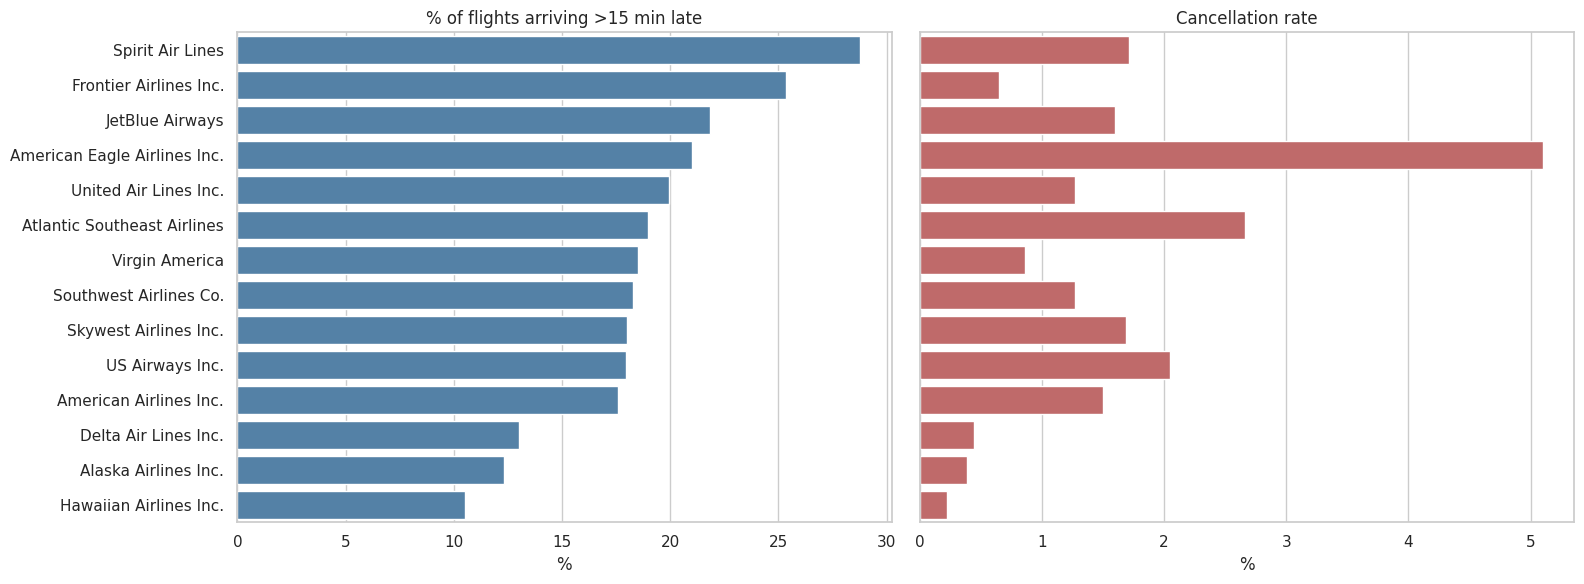

In [ ]:
airline_ops = (ops.groupBy("AIRLINE")
               .agg(F.count("*").alias("flights"),
                    F.round(F.avg("ARRIVAL_DELAY"), 2).alias("avg_arr_delay"),
                    F.percentile_approx("ARRIVAL_DELAY", 0.5).alias("median_arr_delay"),
                    F.percentile_approx("ARRIVAL_DELAY", 0.9).alias("p90_arr_delay"),
                    F.round(100 * F.avg("IS_DELAYED"), 2).alias("pct_delayed")))
airline_cancel = flights_fe.groupBy("AIRLINE").agg(F.round(100 * F.avg("CANCELLED"), 2).alias("cancel_rate_pct"))

airline_score_pd = (airline_ops.join(airline_cancel, "AIRLINE")
                    .join(airlines_lkp, "AIRLINE", "left")
                    .orderBy(F.desc("pct_delayed"))
                    .toPandas())
display(airline_score_pd)

fig, ax = plt.subplots(1, 2, figsize=(16, 6), sharey=True)
sns.barplot(data=airline_score_pd, x="pct_delayed", y="AIRLINE_NAME", color="steelblue", ax=ax[0])
ax[0].set_title("% of flights arriving >15 min late"); ax[0].set_xlabel("%"); ax[0].set_ylabel("")
sns.barplot(data=airline_score_pd, x="cancel_rate_pct", y="AIRLINE_NAME", color="indianred", ax=ax[1])
ax[1].set_title("Cancellation rate"); ax[1].set_xlabel("%"); ax[1].set_ylabel("")
plt.tight_layout(); plt.show()

The median and 90th percentile matter: an airline can look fine on average while still having a long tail of very late flights.

### 4.3 Airports: departure delays, taxi-out congestion and a map

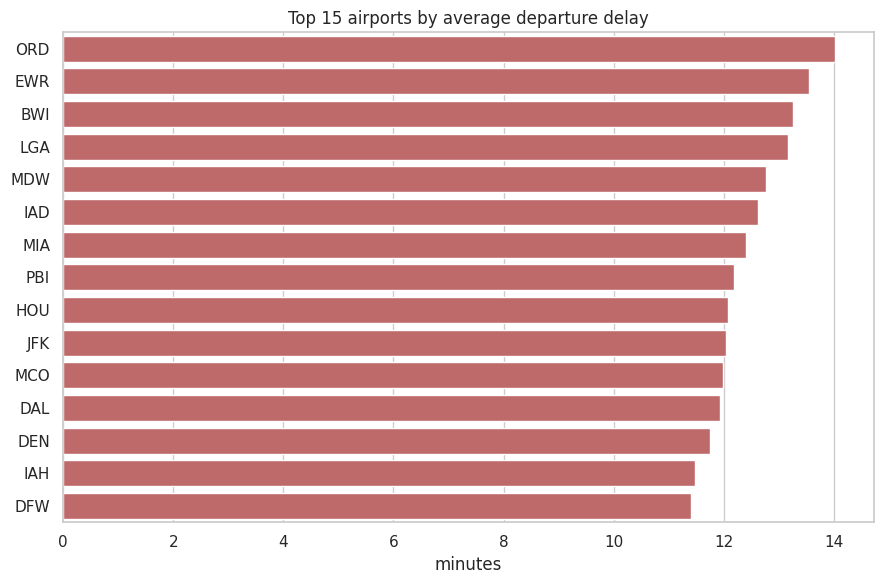

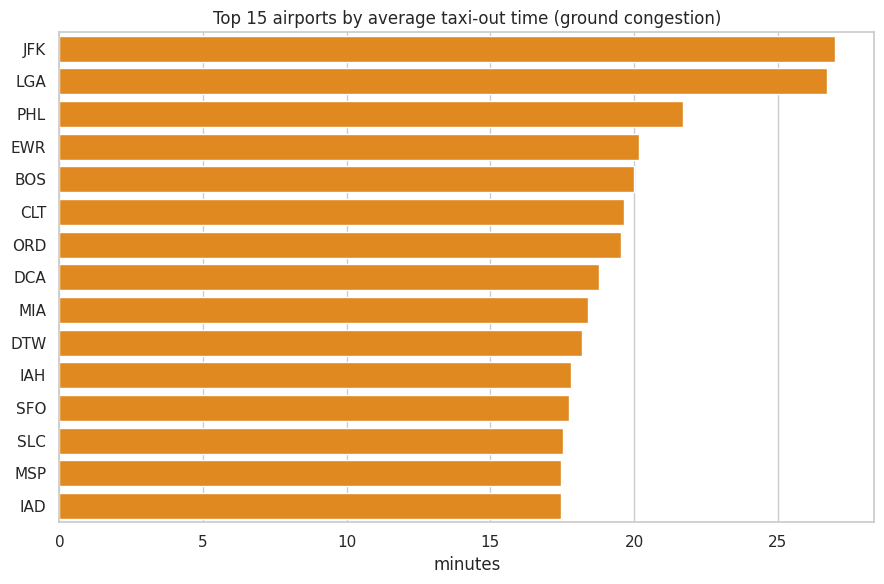

In [ ]:
airport_pd_all = (ops.filter(F.col("ORIGIN_AIRPORT").rlike("^[A-Z]{3}$"))
                  .groupBy("ORIGIN_AIRPORT")
                  .agg(F.count("*").alias("flights"),
                       F.round(F.avg("DEPARTURE_DELAY"), 2).alias("avg_dep_delay"),
                       F.round(F.avg("TAXI_OUT"), 2).alias("avg_taxi_out"),
                       F.round(100 * F.avg("IS_DELAYED"), 2).alias("pct_delayed"))
                  .filter(F.col("flights") >= MIN_AIRPORT_FLIGHTS)
                  .join(airports_lkp, "ORIGIN_AIRPORT", "left")
                  .toPandas())

airport_pd = airport_pd_all.sort_values("avg_dep_delay", ascending=False).head(15)
taxi_pd = airport_pd_all.sort_values("avg_taxi_out", ascending=False).head(15)

barh(airport_pd, "avg_dep_delay", "ORIGIN_AIRPORT", "Top 15 airports by average departure delay", "minutes", "indianred")
barh(taxi_pd, "avg_taxi_out", "ORIGIN_AIRPORT", "Top 15 airports by average taxi-out time (ground congestion)", "minutes", "darkorange")

In [ ]:
geo_pd = airport_pd_all.dropna(subset=["LATITUDE", "LONGITUDE"])
fig = px.scatter_geo(geo_pd, lat="LATITUDE", lon="LONGITUDE", size="flights", color="avg_dep_delay",
                     hover_name="AIRPORT_NAME", hover_data=["ORIGIN_AIRPORT", "flights", "pct_delayed"],
                     scope="usa", color_continuous_scale="RdYlGn_r",
                     title="US airports: bubble size = flights, colour = average departure delay (min)")
fig.show()

### 4.4 Time patterns: month, weekday, hour

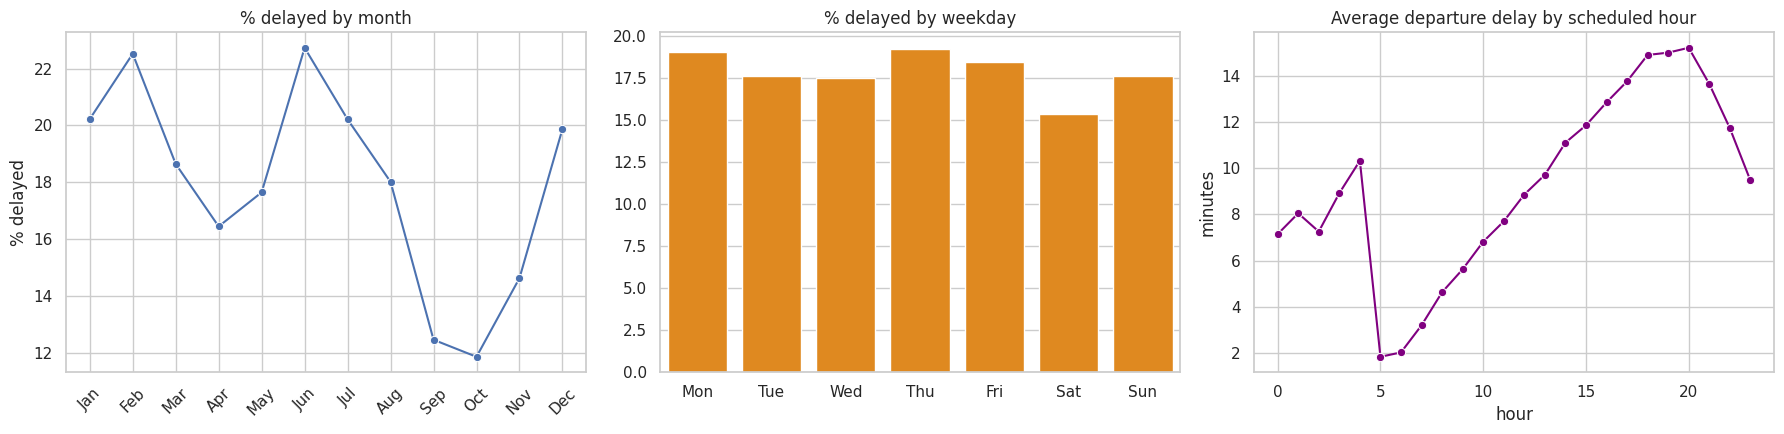

In [ ]:
month_pd = (ops.groupBy("MONTH")
            .agg(F.count("*").alias("flights"),
                 F.round(F.avg("DEPARTURE_DELAY"), 2).alias("avg_dep_delay"),
                 F.round(100 * F.avg("IS_DELAYED"), 2).alias("pct_delayed"))
            .orderBy("MONTH").toPandas())
dow_pd = (ops.groupBy("DAY_OF_WEEK")
          .agg(F.count("*").alias("flights"),
               F.round(F.avg("DEPARTURE_DELAY"), 2).alias("avg_dep_delay"),
               F.round(100 * F.avg("IS_DELAYED"), 2).alias("pct_delayed"))
          .orderBy("DAY_OF_WEEK").toPandas())
dow_pd["DAY"] = dow_pd["DAY_OF_WEEK"].map(day_names)
hour_pd = (ops.groupBy("DEP_HOUR")
           .agg(F.count("*").alias("flights"),
                F.round(F.avg("DEPARTURE_DELAY"), 2).alias("avg_dep_delay"),
                F.round(100 * F.avg("IS_DELAYED"), 2).alias("pct_delayed"))
           .orderBy("DEP_HOUR").toPandas())

fig, ax = plt.subplots(1, 3, figsize=(18, 4.5))
sns.lineplot(data=month_pd, x="MONTH", y="pct_delayed", marker="o", ax=ax[0])
ax[0].set_xticks(range(1, 13)); ax[0].set_xticklabels(month_names, rotation=45)
ax[0].set_title("% delayed by month"); ax[0].set_xlabel(""); ax[0].set_ylabel("% delayed")
sns.barplot(data=dow_pd, x="DAY", y="pct_delayed", color="darkorange", ax=ax[1])
ax[1].set_title("% delayed by weekday"); ax[1].set_xlabel(""); ax[1].set_ylabel("")
sns.lineplot(data=hour_pd, x="DEP_HOUR", y="avg_dep_delay", marker="o", color="purple", ax=ax[2])
ax[2].set_title("Average departure delay by scheduled hour"); ax[2].set_xlabel("hour"); ax[2].set_ylabel("minutes")
plt.tight_layout(); plt.show()

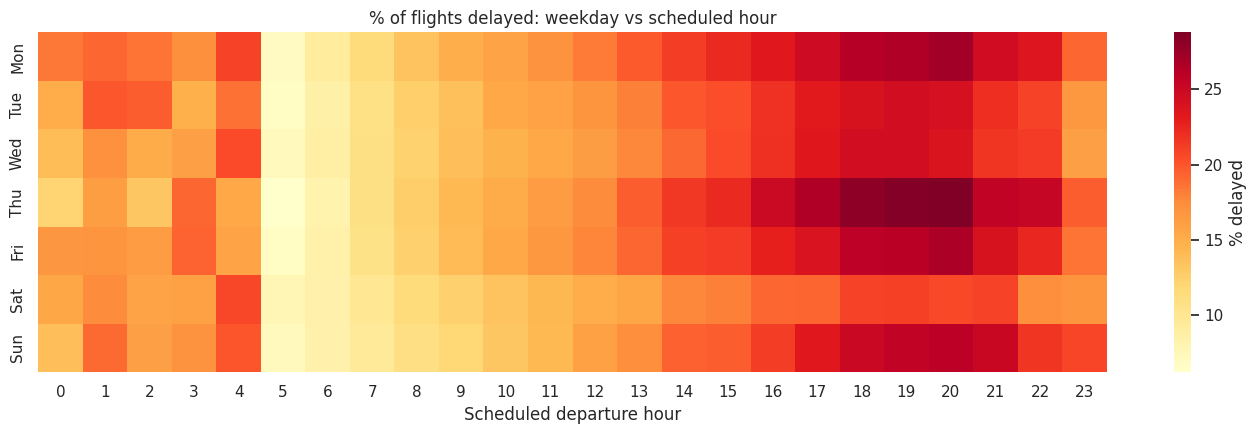

In [ ]:
dow_hour_pd = (ops.groupBy("DAY_OF_WEEK", "DEP_HOUR")
               .agg(F.round(100 * F.avg("IS_DELAYED"), 2).alias("pct_delayed"), F.count("*").alias("flights"))
               .filter(F.col("flights") >= 30)
               .toPandas())
heat = dow_hour_pd.pivot(index="DAY_OF_WEEK", columns="DEP_HOUR", values="pct_delayed")
heat.index = [day_names[i] for i in heat.index]

plt.figure(figsize=(14, 4.5))
sns.heatmap(heat, cmap="YlOrRd", cbar_kws={"label": "% delayed"})
plt.title("% of flights delayed: weekday vs scheduled hour")
plt.xlabel("Scheduled departure hour"); plt.ylabel("")
plt.tight_layout(); plt.show()

### 4.5 Daily trend with a 7-day rolling average (Spark window function)

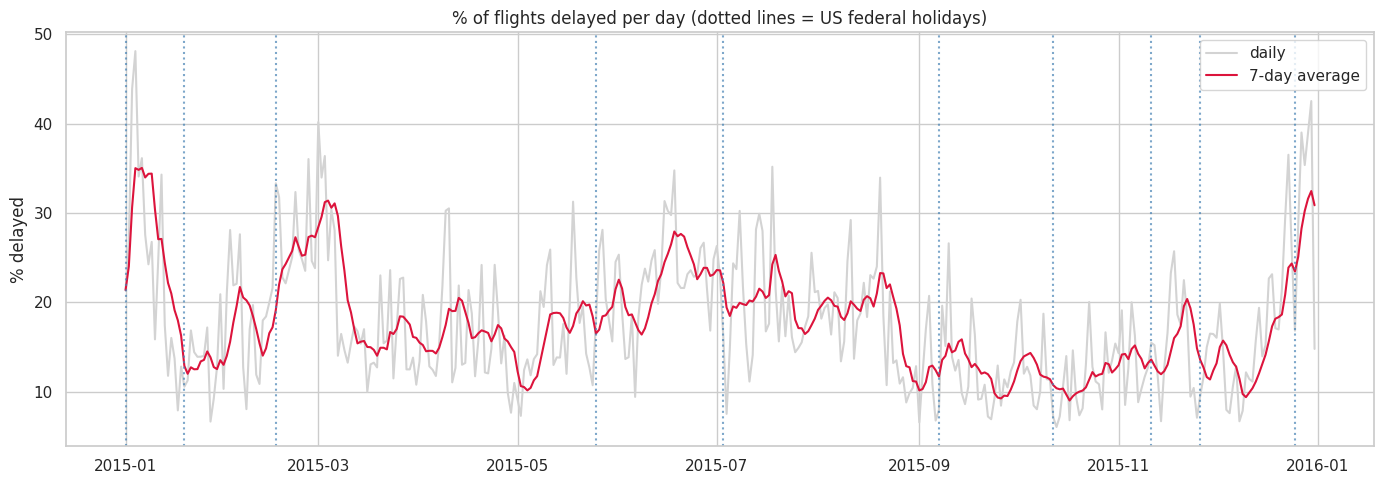

Ten worst days:


,FL_DATE,flights,avg_arr_delay,pct_delayed
3,2015-01-04,15887,31.98,48.12
2,2015-01-03,15050,25.46,43.88
363,2015-12-30,15910,26.17,42.53
59,2015-03-01,13513,25.90,40.18
360,2015-12-27,15198,28.20,39.01
362,2015-12-29,15477,26.30,38.90
356,2015-12-23,16187,20.76,36.52
61,2015-03-03,14970,20.32,36.38
5,2015-01-06,14876,21.30,36.14
56,2015-02-26,15639,20.14,36.04


In [ ]:
daily = (ops.groupBy("FL_DATE")
         .agg(F.count("*").alias("flights"),
              F.round(F.avg("ARRIVAL_DELAY"), 2).alias("avg_arr_delay"),
              F.round(100 * F.avg("IS_DELAYED"), 2).alias("pct_delayed")))

w7 = Window.orderBy("FL_DATE").rowsBetween(-6, 0)
daily_pd = (daily.withColumn("pct_delayed_7d", F.round(F.avg("pct_delayed").over(w7), 2))
            .orderBy("FL_DATE").toPandas())
daily_pd["FL_DATE"] = pd.to_datetime(daily_pd["FL_DATE"])

plt.figure(figsize=(14, 5))
plt.plot(daily_pd["FL_DATE"], daily_pd["pct_delayed"], color="lightgray", label="daily")
plt.plot(daily_pd["FL_DATE"], daily_pd["pct_delayed_7d"], color="crimson", label="7-day average")
for h in holiday_dates:
    plt.axvline(pd.Timestamp(h), color="steelblue", ls=":", alpha=0.7)
plt.title("% of flights delayed per day (dotted lines = US federal holidays)")
plt.ylabel("% delayed"); plt.legend()
plt.tight_layout(); plt.show()

print("Ten worst days:")
display(daily_pd.sort_values("pct_delayed", ascending=False).head(10)[["FL_DATE", "flights", "avg_arr_delay", "pct_delayed"]])

### 4.6 Holiday and weekend effect

,DAY_TYPE,flights,avg_dep_delay,pct_delayed
0,Regular weekday,3890231,9.63,18.50
1,Holiday period (+/-1 day),426952,8.06,16.40
2,Weekend,1396825,8.74,16.73


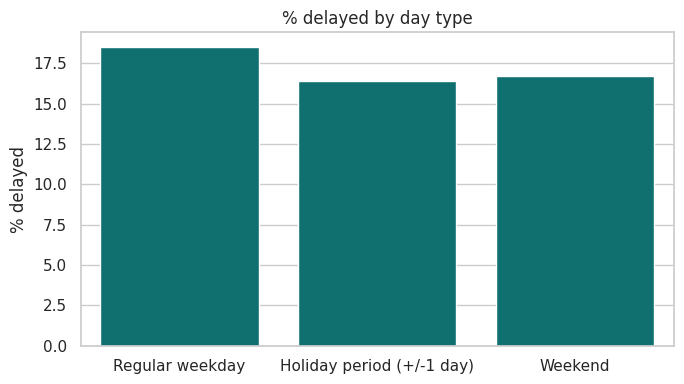

In [ ]:
calendar_pd = (ops.withColumn("DAY_TYPE", F.when(F.col("NEAR_HOLIDAY") == 1, "Holiday period (+/-1 day)")
                                           .when(F.col("IS_WEEKEND") == 1, "Weekend")
                                           .otherwise("Regular weekday"))
               .groupBy("DAY_TYPE")
               .agg(F.count("*").alias("flights"),
                    F.round(F.avg("DEPARTURE_DELAY"), 2).alias("avg_dep_delay"),
                    F.round(100 * F.avg("IS_DELAYED"), 2).alias("pct_delayed"))
               .toPandas())
display(calendar_pd)

plt.figure(figsize=(7, 4))
sns.barplot(data=calendar_pd, x="DAY_TYPE", y="pct_delayed", color="teal")
plt.title("% delayed by day type"); plt.xlabel(""); plt.ylabel("% delayed")
plt.tight_layout(); plt.show()

### 4.7 Routes: busiest and worst

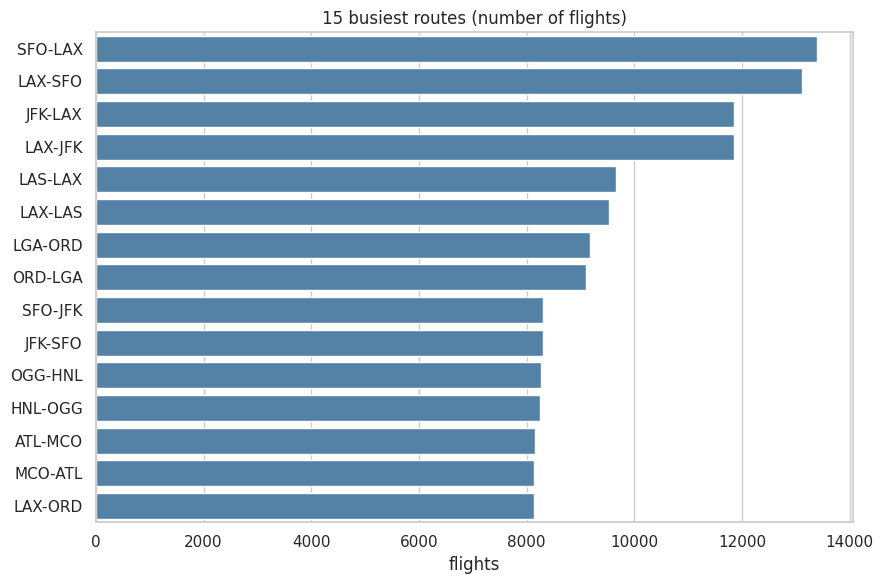

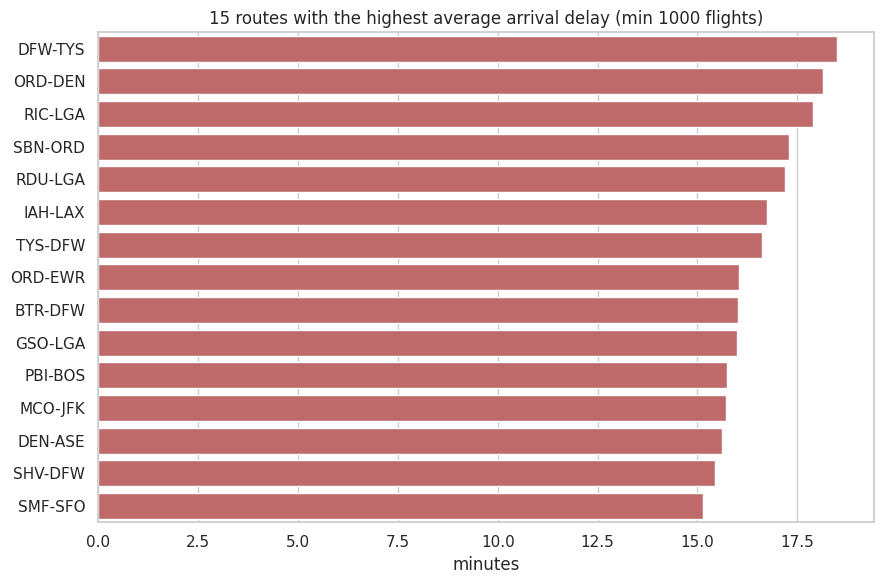

In [ ]:
route_stats = (ops.filter(F.col("ORIGIN_AIRPORT").rlike("^[A-Z]{3}$") & F.col("DESTINATION_AIRPORT").rlike("^[A-Z]{3}$"))
               .groupBy("ROUTE")
               .agg(F.count("*").alias("flights"),
                    F.round(F.avg("ARRIVAL_DELAY"), 2).alias("avg_arr_delay"),
                    F.round(100 * F.avg("IS_DELAYED"), 2).alias("pct_delayed"))
               .filter(F.col("flights") >= MIN_ROUTE_FLIGHTS)
               .toPandas())
route_worst_pd = route_stats.sort_values("avg_arr_delay", ascending=False).head(15)
route_busy_pd = route_stats.sort_values("flights", ascending=False).head(15)

barh(route_busy_pd, "flights", "ROUTE", "15 busiest routes (number of flights)", "flights", "steelblue")
barh(route_worst_pd, "avg_arr_delay", "ROUTE", f"15 routes with the highest average arrival delay (min {MIN_ROUTE_FLIGHTS} flights)", "minutes", "indianred")

### 4.8 Airline vs month heatmap

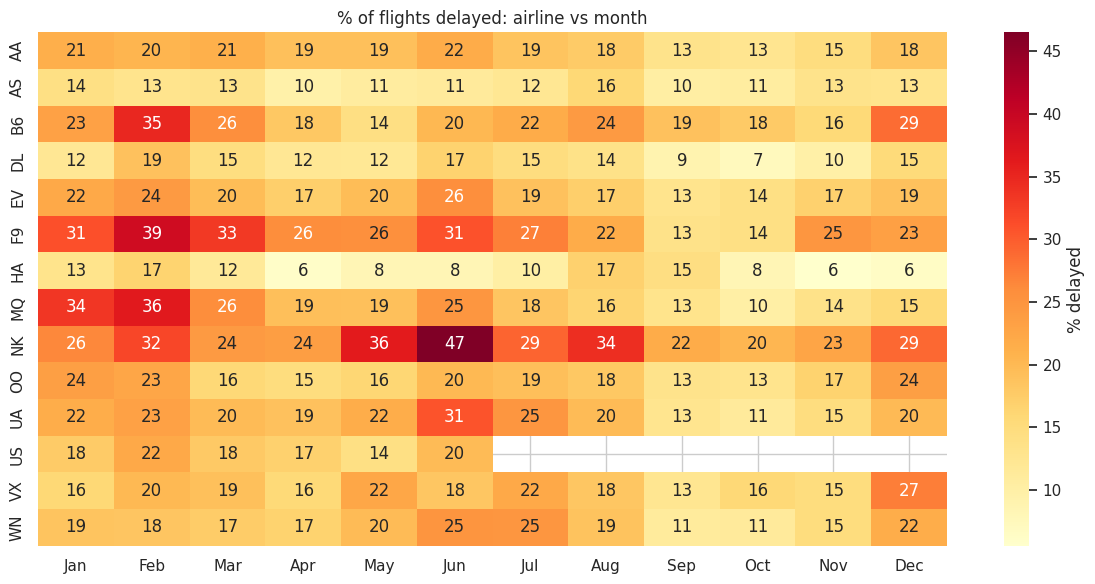

In [ ]:
am_pd = (ops.groupBy("AIRLINE", "MONTH")
         .agg(F.round(100 * F.avg("IS_DELAYED"), 2).alias("pct_delayed")).toPandas())
am = am_pd.pivot(index="AIRLINE", columns="MONTH", values="pct_delayed")
am.columns = [month_names[m - 1] for m in am.columns]

plt.figure(figsize=(12, 6))
sns.heatmap(am, annot=True, fmt=".0f", cmap="YlOrRd", cbar_kws={"label": "% delayed"})
plt.title("% of flights delayed: airline vs month")
plt.ylabel(""); plt.tight_layout(); plt.show()

### 4.9 Delay propagation: does one late aircraft delay the next flight?
Each aircraft (`TAIL_NUMBER`) flies several legs a day. Using a Spark **window function** (`lag`) over each tail number ordered by
scheduled departure time, we attach the previous leg's arrival delay to the next flight, keeping only consecutive legs
(previous destination = this origin).

,PREV_BUCKET,flights,avg_dep_delay,pct_dep_delayed
0,1. Previous leg on time / early,3563137,1.69,7.69
1,2. Previous leg 1-15 min late,1043845,7.16,15.12
2,3. Previous leg 16-60 min late,689459,21.80,50.60
3,4. Previous leg 1-2 hours late,198884,49.72,63.03
4,5. Previous leg over 2 hours late,105133,85.61,59.76


Correlation between previous leg's arrival delay and this flight's departure delay: 0.42


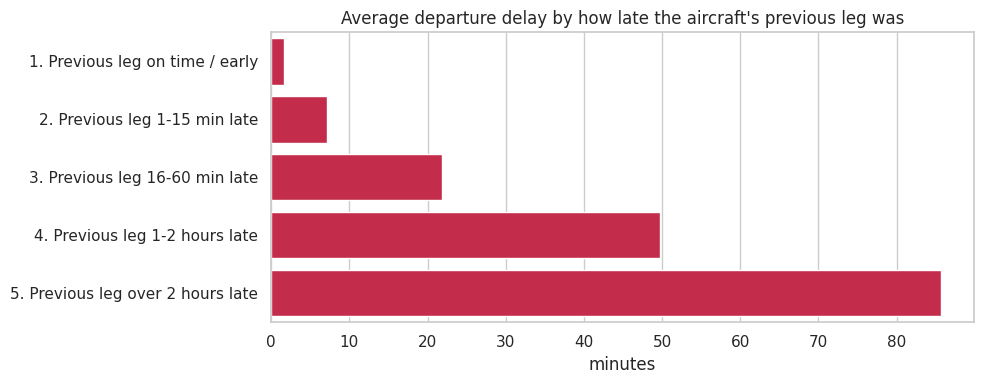

In [ ]:
w_tail = Window.partitionBy("TAIL_NUMBER").orderBy("SCHED_TS")

chain = (ops.filter(F.col("TAIL_NUMBER").isNotNull())
         .select("TAIL_NUMBER", "SCHED_TS", "ORIGIN_AIRPORT", "DESTINATION_AIRPORT", "DEPARTURE_DELAY", "ARRIVAL_DELAY")
         .withColumn("PREV_ARR_DELAY", F.lag("ARRIVAL_DELAY").over(w_tail))
         .withColumn("PREV_DEST", F.lag("DESTINATION_AIRPORT").over(w_tail))
         .filter(F.col("PREV_DEST") == F.col("ORIGIN_AIRPORT"))
         .withColumn("PREV_BUCKET",
                     F.when(F.col("PREV_ARR_DELAY") <= 0, "1. Previous leg on time / early")
                      .when(F.col("PREV_ARR_DELAY") <= 15, "2. Previous leg 1-15 min late")
                      .when(F.col("PREV_ARR_DELAY") <= 60, "3. Previous leg 16-60 min late")
                      .when(F.col("PREV_ARR_DELAY") <= 120, "4. Previous leg 1-2 hours late")
                      .otherwise("5. Previous leg over 2 hours late")))

chain_pd = (chain.groupBy("PREV_BUCKET")
            .agg(F.count("*").alias("flights"),
                 F.round(F.avg("DEPARTURE_DELAY"), 2).alias("avg_dep_delay"),
                 F.round(100 * F.avg((F.col("DEPARTURE_DELAY") > 15).cast("int")), 2).alias("pct_dep_delayed"))
            .orderBy("PREV_BUCKET").toPandas())
display(chain_pd)

corr_prev = chain.stat.corr("PREV_ARR_DELAY", "DEPARTURE_DELAY")
print(f"Correlation between previous leg's arrival delay and this flight's departure delay: {corr_prev:.2f}")

barh(chain_pd, "avg_dep_delay", "PREV_BUCKET", "Average departure delay by how late the aircraft's previous leg was",
     "minutes", "crimson", figsize=(10, 4))

### 4.10 What causes delays, by airline

Share of all attributed delay minutes:
Air system (ATC/NAS)    22.9
Security                 0.1
Airline                 32.2
Late aircraft           39.8
Weather                  4.9


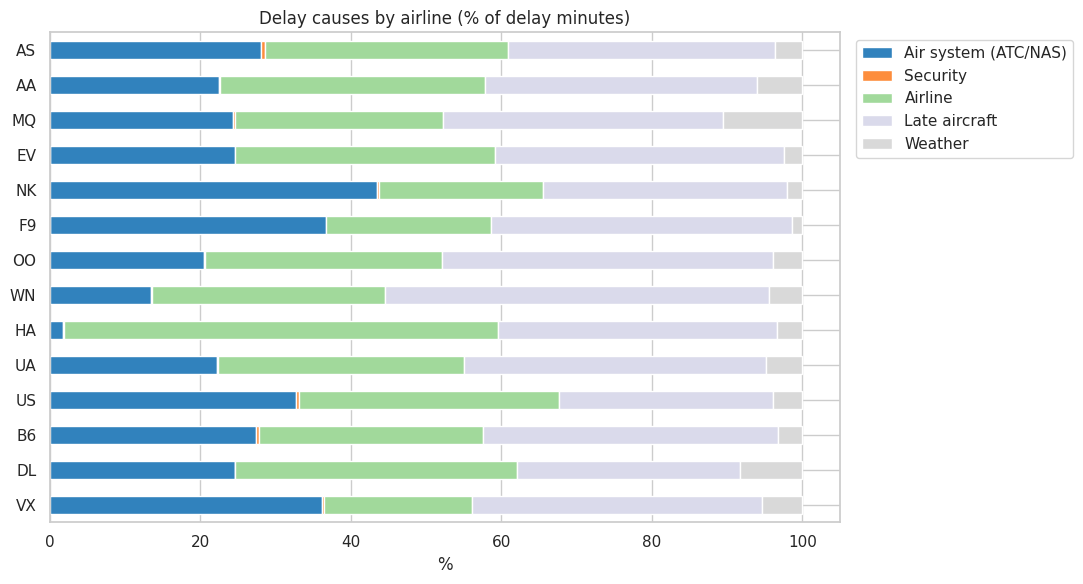

In [ ]:
cause_cols = ["AIR_SYSTEM_DELAY", "SECURITY_DELAY", "AIRLINE_DELAY", "LATE_AIRCRAFT_DELAY", "WEATHER_DELAY"]
cause_labels = {"AIR_SYSTEM_DELAY": "Air system (ATC/NAS)", "SECURITY_DELAY": "Security",
                "AIRLINE_DELAY": "Airline", "LATE_AIRCRAFT_DELAY": "Late aircraft", "WEATHER_DELAY": "Weather"}

cause_airline_pd = (ops.groupBy("AIRLINE").agg(*[F.sum(c).alias(c) for c in cause_cols])
                    .toPandas().set_index("AIRLINE").fillna(0).astype(float))
cause_total = cause_airline_pd.sum()
print("Share of all attributed delay minutes:")
print((100 * cause_total / cause_total.sum()).round(1).rename(index=cause_labels).to_string())

cause_share = cause_airline_pd.div(cause_airline_pd.sum(axis=1), axis=0).mul(100).rename(columns=cause_labels)
cause_share.plot(kind="barh", stacked=True, figsize=(11, 6), colormap="tab20c")
plt.title("Delay causes by airline (% of delay minutes)")
plt.xlabel("%"); plt.ylabel("")
plt.legend(bbox_to_anchor=(1.01, 1), loc="upper left")
plt.tight_layout(); plt.show()

### 4.11 Does distance matter?

In [ ]:
dist_order = ["Short (<500 mi)", "Medium (500-1500 mi)", "Long (>1500 mi)"]
dist_pd = (ops.groupBy("DIST_BUCKET")
           .agg(F.count("*").alias("flights"),
                F.round(F.avg("DEPARTURE_DELAY"), 2).alias("avg_dep_delay"),
                F.round(F.avg("ARRIVAL_DELAY"), 2).alias("avg_arr_delay"),
                F.round(100 * F.avg("IS_DELAYED"), 2).alias("pct_delayed"))
           .toPandas())
dist_pd["DIST_BUCKET"] = pd.Categorical(dist_pd["DIST_BUCKET"], categories=dist_order, ordered=True)
dist_pd = dist_pd.sort_values("DIST_BUCKET")
display(dist_pd)

,DIST_BUCKET,flights,avg_dep_delay,avg_arr_delay,pct_delayed
1,Short (<500 mi),2073950,8.05,5.16,17.53
2,Medium (500-1500 mi),2862690,9.93,4.60,18.27
0,Long (>1500 mi),777368,10.26,1.71,17.62


Compare `avg_dep_delay` with `avg_arr_delay` for each bucket. Longer flights often recover some lost time in the air,
so their arrival delay can be smaller than their departure delay.

### 4.12 Cancellations: by reason and by month

,CANCELLATION_REASON,count,REASON,pct
0,B,48851,Weather,54.35
1,A,25262,Airline/Carrier,28.11
3,C,15749,Air System (NAS),17.52
2,D,22,Security,0.02


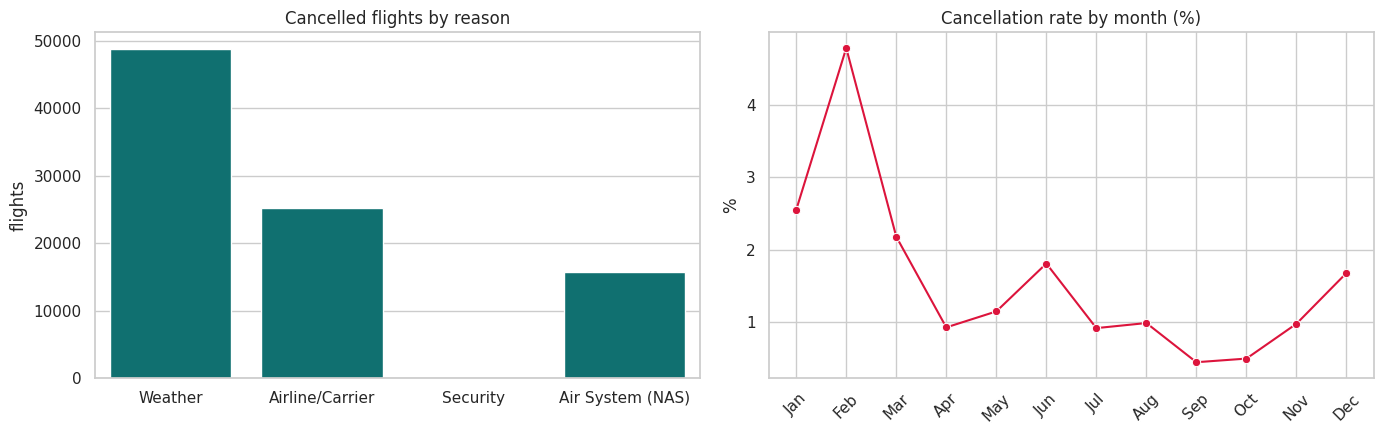

In [ ]:
reason_map = {"A": "Airline/Carrier", "B": "Weather", "C": "Air System (NAS)", "D": "Security"}

cancel_pd = cancelled.groupBy("CANCELLATION_REASON").count().toPandas()
cancel_pd["REASON"] = cancel_pd["CANCELLATION_REASON"].map(reason_map)
cancel_pd["pct"] = (100 * cancel_pd["count"] / cancel_pd["count"].sum()).round(2)
display(cancel_pd.sort_values("count", ascending=False))

cancel_month_pd = (flights_fe.groupBy("MONTH")
                   .agg(F.count("*").alias("scheduled"),
                        F.sum("CANCELLED").alias("cancelled"),
                        F.round(100 * F.avg("CANCELLED"), 2).alias("cancel_rate_pct"))
                   .orderBy("MONTH").toPandas())

fig, ax = plt.subplots(1, 2, figsize=(14, 4.5))
sns.barplot(data=cancel_pd, x="REASON", y="count", color="teal", ax=ax[0])
ax[0].set_title("Cancelled flights by reason"); ax[0].set_xlabel(""); ax[0].set_ylabel("flights")
sns.lineplot(data=cancel_month_pd, x="MONTH", y="cancel_rate_pct", marker="o", color="crimson", ax=ax[1])
ax[1].set_xticks(range(1, 13)); ax[1].set_xticklabels(month_names, rotation=45)
ax[1].set_title("Cancellation rate by month (%)"); ax[1].set_xlabel(""); ax[1].set_ylabel("%")
plt.tight_layout(); plt.show()

# Part 5. Machine learning
**Task A (classification):** will a flight arrive more than 15 minutes late?
**Task B (regression):** by how many minutes?

Two scenarios are compared:
- **Pre-departure:** only information known when the flight is scheduled (month, weekday, hour, distance, airline, congestion, holiday...).
- **Post-departure:** also uses the actual departure delay and taxi-out time. This shows how much predictions improve once the flight is underway.

Design notes: a random sample (`ML_SAMPLE_FRACTION`) keeps training fast on Colab; class weights handle the fact that delayed
flights are the minority; AUC is the main metric because plain accuracy is misleading on imbalanced data.

In [ ]:
from pyspark.ml import Pipeline, PipelineModel
from pyspark.ml.feature import StringIndexer, OneHotEncoder, VectorAssembler
from pyspark.ml.classification import LogisticRegression, RandomForestClassifier, GBTClassifier
from pyspark.ml.regression import LinearRegression, GBTRegressor
from pyspark.ml.evaluation import BinaryClassificationEvaluator, RegressionEvaluator
from pyspark.ml.tuning import CrossValidator, ParamGridBuilder
from pyspark.ml.functions import vector_to_array

base_num = ["MONTH", "DAY_OF_WEEK", "DEP_HOUR", "DISTANCE", "SCHEDULED_TIME",
            "IS_WEEKEND", "NEAR_HOLIDAY", "ORIGIN_HOURLY_FLIGHTS"]
post_num = base_num + ["DEPARTURE_DELAY", "TAXI_OUT"]

feature_cols = ["DEPARTURE_DELAY", "TAXI_OUT"] + base_num
ml_df = (ops.select(F.col("IS_DELAYED").cast("double").alias("label"),
                    F.greatest(F.lit(-30.0), F.least(F.lit(180.0), F.col("ARRIVAL_DELAY").cast("double"))).alias("arr_delay_clipped"),
                    F.col("AIRLINE"),
                    *[F.col(c).cast("double").alias(c) for c in feature_cols])
         .dropna()
         .sample(False, ML_SAMPLE_FRACTION, seed=42))

train, test = ml_df.randomSplit([0.8, 0.2], seed=42)
train.cache(); test.cache()

n_train, n_test = train.count(), test.count()
n_pos = train.filter("label = 1").count()
ratio = (n_train - n_pos) / n_pos
print(f"Train rows: {n_train:,} | Test rows: {n_test:,} | delayed share in train: {100 * n_pos / n_train:.1f}%")

# class weights: delayed flights count more so the model does not just predict "on time"
train_w = train.withColumn("w", F.when(F.col("label") == 1, F.lit(ratio)).otherwise(F.lit(1.0)))

Train rows: 457,452 | Test rows: 114,138 | delayed share in train: 17.9%


### 5.1 Classification: three models, two scenarios

Logistic Regression    pre-departure   AUC=0.625  recall=0.597  (20s)
Random Forest          pre-departure   AUC=0.645  recall=0.626  (58s)
Gradient-Boosted Trees pre-departure   AUC=0.656  recall=0.631  (93s)
Gradient-Boosted Trees post-departure  AUC=0.965  recall=0.889  (87s)


,model,scenario,AUC,accuracy,precision,recall,F1,train_seconds
0,Logistic Regression,pre-departure,0.6248,0.5905,0.2426,0.5965,0.3450,20.1
1,Random Forest,pre-departure,0.6446,0.5880,0.2474,0.6263,0.3546,57.7
2,Gradient-Boosted Trees,pre-departure,0.6564,0.5975,0.2536,0.6308,0.3617,93.0
3,Gradient-Boosted Trees,post-departure,0.9652,0.9232,0.7388,0.8895,0.8072,86.7


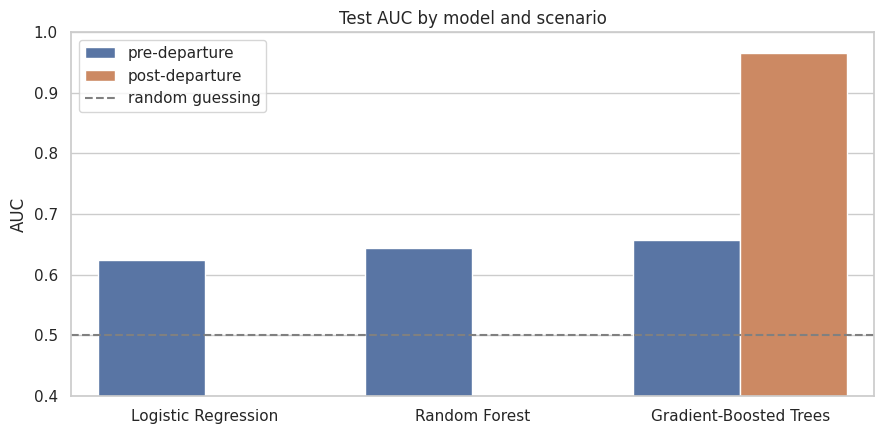

In [ ]:
def build_pipeline(estimator, numeric_cols):
    return Pipeline(stages=[
        StringIndexer(inputCol="AIRLINE", outputCol="AIRLINE_IDX"),
        OneHotEncoder(inputCols=["AIRLINE_IDX"], outputCols=["AIRLINE_VEC"]),
        VectorAssembler(inputCols=numeric_cols + ["AIRLINE_VEC"], outputCol="features"),
        estimator])

def eval_classifier(model, name, scenario):
    pred = model.transform(test)
    auc = BinaryClassificationEvaluator(metricName="areaUnderROC").evaluate(pred)
    cm = {(r["label"], r["prediction"]): r["count"] for r in pred.groupBy("label", "prediction").count().collect()}
    tp, fp = cm.get((1.0, 1.0), 0), cm.get((0.0, 1.0), 0)
    fn, tn = cm.get((1.0, 0.0), 0), cm.get((0.0, 0.0), 0)
    precision = tp / (tp + fp) if tp + fp else 0.0
    recall = tp / (tp + fn) if tp + fn else 0.0
    f1 = 2 * precision * recall / (precision + recall) if precision + recall else 0.0
    return {"model": name, "scenario": scenario, "AUC": round(auc, 4),
            "accuracy": round((tp + tn) / (tp + tn + fp + fn), 4),
            "precision": round(precision, 4), "recall": round(recall, 4), "F1": round(f1, 4),
            "_cm": (tn, fp, fn, tp)}

results, models = [], {}

def fit_and_eval(name, scenario, estimator, numeric_cols):
    t0 = time.time()
    model = build_pipeline(estimator, numeric_cols).fit(train_w)
    secs = time.time() - t0
    res = eval_classifier(model, name, scenario)
    res["train_seconds"] = round(secs, 1)
    results.append(res); models[(name, scenario)] = model
    print(f"{name:<22} {scenario:<15} AUC={res['AUC']:.3f}  recall={res['recall']:.3f}  ({secs:.0f}s)")
    return model

fit_and_eval("Logistic Regression", "pre-departure", LogisticRegression(weightCol="w", maxIter=30), base_num)
fit_and_eval("Random Forest", "pre-departure", RandomForestClassifier(weightCol="w", numTrees=40, maxDepth=8, seed=42), base_num)
fit_and_eval("Gradient-Boosted Trees", "pre-departure", GBTClassifier(weightCol="w", maxIter=30, maxDepth=5, seed=42), base_num)
fit_and_eval("Gradient-Boosted Trees", "post-departure", GBTClassifier(weightCol="w", maxIter=30, maxDepth=5, seed=42), post_num)

results_pd = pd.DataFrame(results)
display(results_pd.drop(columns=["_cm"]))

plt.figure(figsize=(9, 4.5))
sns.barplot(data=results_pd, x="model", y="AUC", hue="scenario")
plt.ylim(0.4, 1.0); plt.axhline(0.5, color="gray", ls="--", label="random guessing")
plt.title("Test AUC by model and scenario"); plt.xlabel(""); plt.legend()
plt.tight_layout(); plt.show()

Expect the pre-departure models to be only modestly better than random guessing, because much of what causes a delay (weather,
air traffic, an earlier late flight) is not in scheduled information. The post-departure model should be far stronger, since
a flight that already left late usually arrives late. Both results are worth discussing in your report.

### 5.2 Confusion matrix and feature importance

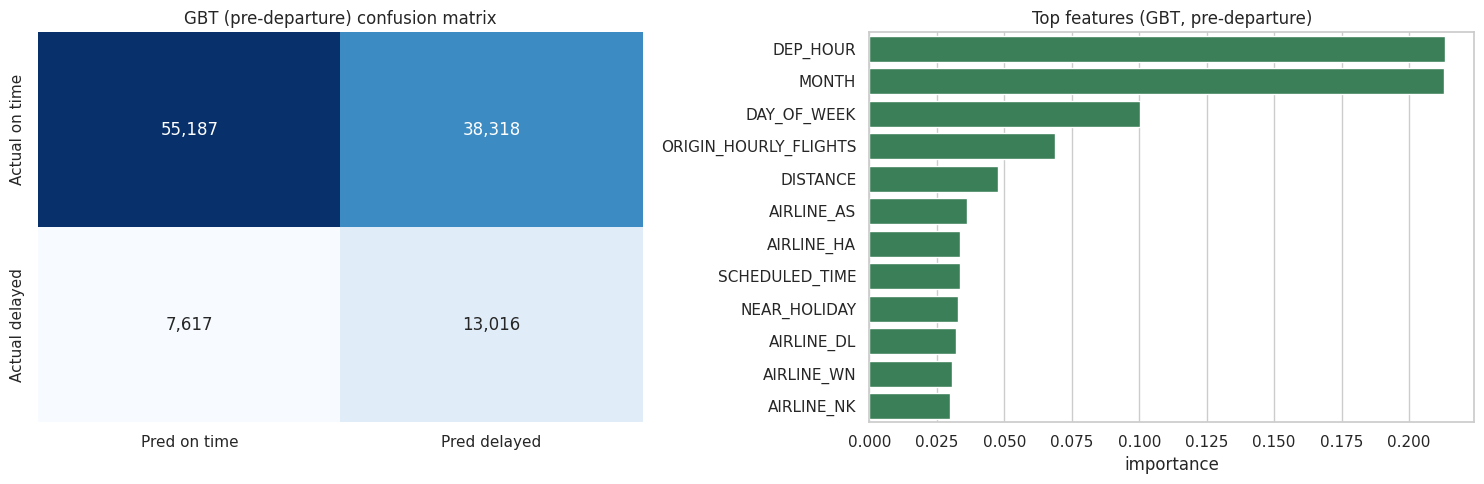

In [ ]:
gbt_pre = models[("Gradient-Boosted Trees", "pre-departure")]
tn, fp, fn, tp = results_pd[(results_pd["model"] == "Gradient-Boosted Trees") & (results_pd["scenario"] == "pre-departure")]["_cm"].iloc[0]

fig, ax = plt.subplots(1, 2, figsize=(15, 5))
sns.heatmap([[tn, fp], [fn, tp]], annot=True, fmt=",", cmap="Blues", cbar=False, ax=ax[0],
            xticklabels=["Pred on time", "Pred delayed"], yticklabels=["Actual on time", "Actual delayed"])
ax[0].set_title("GBT (pre-departure) confusion matrix")

labels = gbt_pre.stages[0].labels
names = base_num + [f"AIRLINE_{l}" for l in labels[:-1]]
imp = gbt_pre.stages[-1].featureImportances.toArray()
if len(names) != len(imp):
    names = [f"feature_{i}" for i in range(len(imp))]
imp_pd = pd.DataFrame({"feature": names, "importance": imp}).sort_values("importance", ascending=False).head(12)
sns.barplot(data=imp_pd, x="importance", y="feature", color="seagreen", ax=ax[1])
ax[1].set_title("Top features (GBT, pre-departure)"); ax[1].set_ylabel("")
plt.tight_layout(); plt.show()

### 5.3 Hyperparameter tuning with cross-validation (Logistic Regression)

In [ ]:
lr = LogisticRegression(weightCol="w", maxIter=30)
pipe = build_pipeline(lr, base_num)
grid = (ParamGridBuilder()
        .addGrid(lr.regParam, [0.0, 0.01, 0.1])
        .addGrid(lr.elasticNetParam, [0.0, 0.5])
        .build())
cv = CrossValidator(estimator=pipe, estimatorParamMaps=grid,
                    evaluator=BinaryClassificationEvaluator(metricName="areaUnderROC"),
                    numFolds=3, parallelism=2, seed=42)

t0 = time.time()
cv_model = cv.fit(train_w)
print(f"Cross-validation took {time.time() - t0:.0f}s")

for p, m in zip(grid, cv_model.avgMetrics):
    print({k.name: v for k, v in p.items()}, "-> CV AUC", round(m, 4))

best_lr = cv_model.bestModel.stages[-1]
print("Best regParam:", best_lr.getRegParam(), "| best elasticNetParam:", best_lr.getElasticNetParam())

Cross-validation took 170s
{'regParam': 0.0, 'elasticNetParam': 0.0} -> CV AUC 0.6277
{'regParam': 0.0, 'elasticNetParam': 0.5} -> CV AUC 0.6277
{'regParam': 0.01, 'elasticNetParam': 0.0} -> CV AUC 0.6278
{'regParam': 0.01, 'elasticNetParam': 0.5} -> CV AUC 0.6263
{'regParam': 0.1, 'elasticNetParam': 0.0} -> CV AUC 0.6277
{'regParam': 0.1, 'elasticNetParam': 0.5} -> CV AUC 0.6043
Best regParam: 0.01 | best elasticNetParam: 0.0


### 5.4 Regression: how many minutes late?

In [ ]:
def eval_reg(model, name, scenario):
    pred = model.transform(test)
    ev = RegressionEvaluator(labelCol="arr_delay_clipped", predictionCol="prediction")
    return {"model": name, "scenario": scenario,
            "RMSE": round(ev.setMetricName("rmse").evaluate(pred), 2),
            "MAE": round(ev.setMetricName("mae").evaluate(pred), 2),
            "R2": round(ev.setMetricName("r2").evaluate(pred), 4)}

mean_delay = train.agg(F.avg("arr_delay_clipped")).first()[0]
baseline_rmse = test.select(F.sqrt(F.avg(F.pow(F.col("arr_delay_clipped") - F.lit(mean_delay), 2)))).first()[0]
baseline_mae = test.select(F.avg(F.abs(F.col("arr_delay_clipped") - F.lit(mean_delay)))).first()[0]
reg_results = [{"model": "Baseline (always predict the mean)", "scenario": "-",
                "RMSE": round(baseline_rmse, 2), "MAE": round(baseline_mae, 2), "R2": 0.0}]

reg_models = {
    ("Linear Regression", "pre-departure"): (LinearRegression(labelCol="arr_delay_clipped"), base_num),
    ("GBT Regressor", "pre-departure"): (GBTRegressor(labelCol="arr_delay_clipped", maxIter=30, maxDepth=5, seed=42), base_num),
    ("GBT Regressor", "post-departure"): (GBTRegressor(labelCol="arr_delay_clipped", maxIter=30, maxDepth=5, seed=42), post_num),
}
for (name, scenario), (est, cols) in reg_models.items():
    m = build_pipeline(est, cols).fit(train)
    reg_results.append(eval_reg(m, name, scenario))

reg_pd = pd.DataFrame(reg_results)
display(reg_pd)

,model,scenario,RMSE,MAE,R2
0,Baseline (always predict the mean),-,32.39,20.05,0.0000
1,Linear Regression,pre-departure,31.97,19.72,0.0257
2,GBT Regressor,pre-departure,31.59,19.44,0.0487
3,GBT Regressor,post-departure,11.69,7.97,0.8697


Delay minutes are clipped to the range -30 to +180 for training so a handful of extreme delays (over 24 hours) do not dominate the loss.
Report RMSE and MAE in minutes, and compare with the baseline to show whether the model adds value.

### 5.5 Save the model and score new flights

In [ ]:
MODEL_PATH = f"{WORK}/models/gbt_delay_pipeline"
gbt_pre.write().overwrite().save(MODEL_PATH)

loaded = PipelineModel.load(MODEL_PATH)
(loaded.transform(test.limit(8))
       .select("AIRLINE", "MONTH", "DEP_HOUR", "DISTANCE", "label",
               F.round(vector_to_array("probability")[1], 3).alias("prob_delayed"), "prediction")
       .show())

+-------+-----+--------+--------+-----+------------+----------+
|AIRLINE|MONTH|DEP_HOUR|DISTANCE|label|prob_delayed|prediction|
+-------+-----+--------+--------+-----+------------+----------+
|     AA|  4.0|     7.0|   431.0|  0.0|       0.312|       0.0|
|     AA|  9.0|    20.0|   857.0|  0.0|       0.502|       1.0|
|     AA|  4.0|     1.0|  1709.0|  0.0|       0.315|       0.0|
|     AA|  3.0|    11.0|  2165.0|  0.0|       0.463|       0.0|
|     AA| 11.0|    20.0|  1739.0|  0.0|       0.497|       0.0|
|     AA| 11.0|     6.0|   861.0|  0.0|       0.298|       0.0|
|     AA| 12.0|    11.0|   733.0|  0.0|       0.469|       0.0|
|     AA|  1.0|     9.0|  2475.0|  0.0|       0.527|       1.0|
+-------+-----+--------+--------+-----+------------+----------+



# Part 6. Performance engineering
The same aggregation is run under different Spark configurations, so you can show **why** big data tooling choices matter.
Timings depend on your Colab hardware, so always report your own numbers and describe the setup.

In [ ]:
bench = []

def noop(df):
    # executes the whole plan without collecting results to the driver
    df.write.format("noop").mode("overwrite").save()

def bench_run(label, fn):
    t0 = time.time(); fn(); s = time.time() - t0
    bench.append({"experiment": label, "seconds": round(s, 2)})
    print(f"{label:<55} {s:7.2f}s")

def agg_query(df):
    return (df.filter((F.col("CANCELLED") == 0) & F.col("ARRIVAL_DELAY").isNotNull())
              .groupBy("AIRLINE", "MONTH").agg(F.avg("ARRIVAL_DELAY").alias("avg_arr_delay")))

### 6.1 Storage format and partition pruning

In [ ]:
bench_run("CSV, schema inferred (extra pass over the file)",
          lambda: noop(agg_query(spark.read.csv(f"{path}/flights.csv", header=True, inferSchema=True))))
bench_run("CSV, schema supplied",
          lambda: noop(agg_query(spark.read.csv(f"{path}/flights.csv", header=True, schema=csv_schema))))
bench_run("Parquet (all months)",
          lambda: noop(agg_query(spark.read.parquet(PARQUET))))
bench_run("Parquet, one month only (partition pruning)",
          lambda: noop(agg_query(spark.read.parquet(PARQUET).filter("MONTH = 1"))))

CSV, schema inferred (extra pass over the file)           41.37s
CSV, schema supplied                                      12.92s
Parquet (all months)                                       1.32s
Parquet, one month only (partition pruning)                0.29s


### 6.2 Caching

In [ ]:
cached = spark.read.parquet(PARQUET).cache()
bench_run("Cache materialisation (first action)", lambda: cached.count())
bench_run("Aggregation on cached DataFrame", lambda: noop(agg_query(cached)))
cached.unpersist()

Cache materialisation (first action)                      47.32s
Aggregation on cached DataFrame                            1.46s


DataFrame[YEAR: int, DAY: int, DAY_OF_WEEK: int, AIRLINE: string, FLIGHT_NUMBER: int, TAIL_NUMBER: string, ORIGIN_AIRPORT: string, DESTINATION_AIRPORT: string, SCHEDULED_DEPARTURE: int, DEPARTURE_TIME: int, DEPARTURE_DELAY: int, TAXI_OUT: int, WHEELS_OFF: int, SCHEDULED_TIME: int, ELAPSED_TIME: int, AIR_TIME: int, DISTANCE: int, WHEELS_ON: int, TAXI_IN: int, SCHEDULED_ARRIVAL: int, ARRIVAL_TIME: int, ARRIVAL_DELAY: int, DIVERTED: int, CANCELLED: int, CANCELLATION_REASON: string, AIR_SYSTEM_DELAY: int, SECURITY_DELAY: int, AIRLINE_DELAY: int, LATE_AIRCRAFT_DELAY: int, WEATHER_DELAY: int, MONTH: int]

### 6.3 Shuffle partitions (adaptive execution switched off for a fair test)

In [ ]:
spark.conf.set("spark.sql.adaptive.enabled", "false")
for n in [4, 16, 200]:
    spark.conf.set("spark.sql.shuffle.partitions", str(n))
    bench_run(f"spark.sql.shuffle.partitions = {n}",
              lambda: noop(agg_query(spark.read.parquet(PARQUET))))
spark.conf.set("spark.sql.shuffle.partitions", "16")

spark.sql.shuffle.partitions = 4                           1.14s
spark.sql.shuffle.partitions = 16                          1.14s
spark.sql.shuffle.partitions = 200                         1.66s


### 6.4 Join strategy: sort-merge join vs broadcast join

In [ ]:
base = spark.read.parquet(PARQUET)

spark.conf.set("spark.sql.autoBroadcastJoinThreshold", "-1")
smj = base.join(airlines_lkp, "AIRLINE")
bench_run("Join with airlines: sort-merge join (broadcast disabled)", lambda: noop(smj))

spark.conf.set("spark.sql.autoBroadcastJoinThreshold", str(10 * 1024 * 1024))
bj = base.join(F.broadcast(airlines_lkp), "AIRLINE")
bench_run("Join with airlines: broadcast hash join", lambda: noop(bj))

print("\n--- Physical plan (sort-merge) ---"); smj.explain()
print("\n--- Physical plan (broadcast) ---");  bj.explain()

spark.conf.set("spark.sql.adaptive.enabled", "true")

Join with airlines: sort-merge join (broadcast disabled)   24.63s
Join with airlines: broadcast hash join                   10.07s

--- Physical plan (sort-merge) ---
== Physical Plan ==
*(2) Project [AIRLINE#89274, YEAR#89271, DAY#89272, DAY_OF_WEEK#89273, FLIGHT_NUMBER#89275, TAIL_NUMBER#89276, ORIGIN_AIRPORT#89277, DESTINATION_AIRPORT#89278, SCHEDULED_DEPARTURE#89279, DEPARTURE_TIME#89280, DEPARTURE_DELAY#89281, TAXI_OUT#89282, WHEELS_OFF#89283, SCHEDULED_TIME#89284, ELAPSED_TIME#89285, AIR_TIME#89286, DISTANCE#89287, WHEELS_ON#89288, TAXI_IN#89289, SCHEDULED_ARRIVAL#89290, ARRIVAL_TIME#89291, ARRIVAL_DELAY#89292, DIVERTED#89293, CANCELLED#89294, ... 8 more fields]
+- *(2) BroadcastHashJoin [AIRLINE#89274], [AIRLINE#328], Inner, BuildRight, false
   :- *(2) Filter isnotnull(AIRLINE#89274)
   :  +- *(2) ColumnarToRow
   :     +- FileScan parquet [YEAR#89271,DAY#89272,DAY_OF_WEEK#89273,AIRLINE#89274,FLIGHT_NUMBER#89275,TAIL_NUMBER#89276,ORIGIN_AIRPORT#89277,DESTINATION_AIRPORT#89278,S

### 6.5 Spark vs Pandas on the same file

Pandas: 24.36s


,experiment,seconds
0,"CSV, schema inferred (extra pass over the file)",41.37
1,"CSV, schema supplied",12.92
2,Parquet (all months),1.32
3,"Parquet, one month only (partition pruning)",0.29
4,Cache materialisation (first action),47.32
5,Aggregation on cached DataFrame,1.46
6,spark.sql.shuffle.partitions = 4,1.14
7,spark.sql.shuffle.partitions = 16,1.14
8,spark.sql.shuffle.partitions = 200,1.66
9,Join with airlines: sort-merge join (broadcast...,24.63


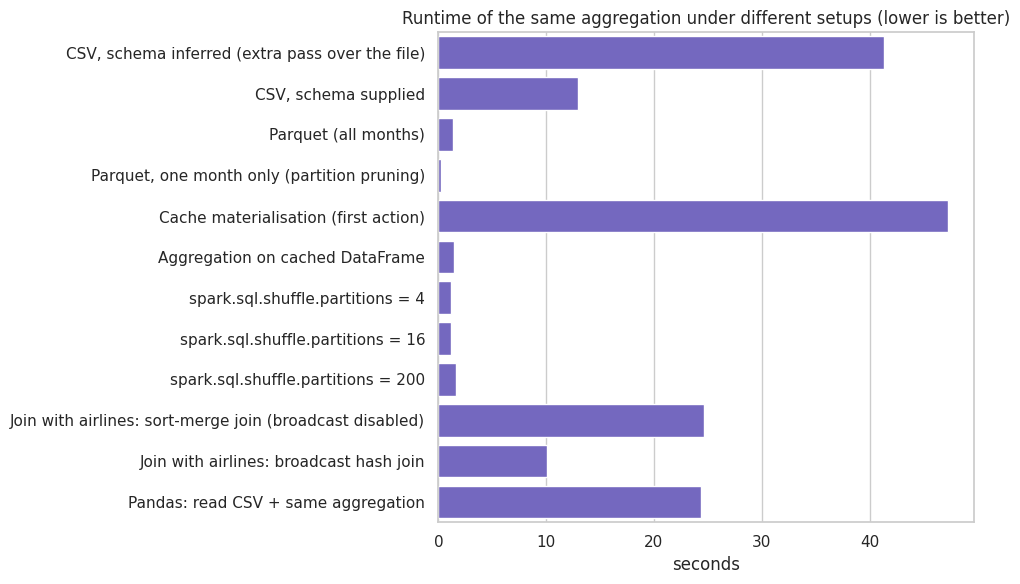

In [ ]:
if RUN_PANDAS_COMPARISON:
    t0 = time.time()
    pdf = pd.read_csv(f"{path}/flights.csv", low_memory=False)
    _ = (pdf[(pdf["CANCELLED"] == 0) & pdf["ARRIVAL_DELAY"].notna()]
         .groupby(["AIRLINE", "MONTH"])["ARRIVAL_DELAY"].mean())
    s = time.time() - t0
    bench.append({"experiment": "Pandas: read CSV + same aggregation", "seconds": round(s, 2)})
    print(f"Pandas: {s:.2f}s")
    del pdf, _

bench_pd = pd.DataFrame(bench)
display(bench_pd)

plt.figure(figsize=(10, 6))
sns.barplot(data=bench_pd, x="seconds", y="experiment", color="slateblue")
plt.title("Runtime of the same aggregation under different setups (lower is better)")
plt.xlabel("seconds"); plt.ylabel("")
plt.tight_layout(); plt.show()

**How to interpret this:** Parquet should beat CSV because it is columnar, compressed and carries its own schema, so Spark reads only the
columns it needs. Partition pruning skips whole months. Broadcasting a tiny table avoids shuffling the large one. On a single
Colab machine Pandas can be competitive at 5.8M rows; Spark's advantage is that the same code keeps working when the data no
longer fits on one machine.